Run this to load the modules, boot up the PyTorch environment, and dynamically import the dataloader.

In [4]:
import os
import sys
sys.path.append(os.path.abspath('..'))
import torch
import numpy as np
import matplotlib.pyplot as plt
import importlib.util
import warnings

warnings.filterwarnings('ignore')

from src.pipeline.aollsm_dataloader import AOLLSMDataset
from torch.utils.data import DataLoader
from src.models.spatial_compressor import SpatialCompressor
from src.models.vector_seq_engine import VectorSeqEngine

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Booting MELD End-to-End Compiler on: {device.type.upper()}")

[*] Booting MELD End-to-End Compiler on: CPU


This cell ingests LLSM data, executes the 2D max-projection, and visually renders the cell. If this renders as a black box, your crop dimensions in the dataloader are hitting empty fluid.

[*] Ingesting AO-LLSM Optical Telemetry...
[INIT] AOLLSMDataset initialized with 1 sample(s) in: ../dataset/raw_tiffs
[*] Loaded Raw Tensor Shape: torch.Size([1, 10, 2, 128, 128, 128]) -> [Batch, Time, Channel, Depth, Height, Width]


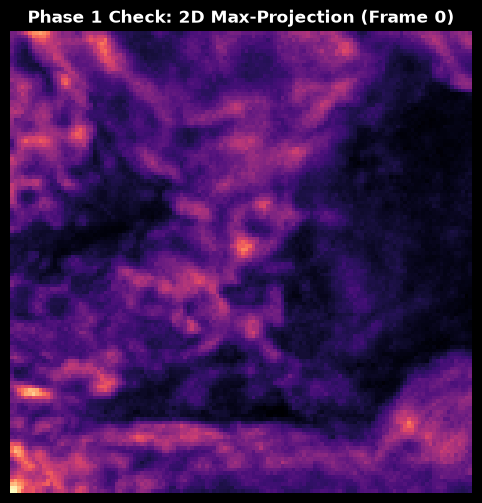

In [5]:
print("[*] Ingesting AO-LLSM Optical Telemetry...")
data_dir = "../dataset/raw_tiffs" 
SEQUENCE_LENGTH = 10 

# Initialize the dataset
dataset = AOLLSMDataset(data_dir=data_dir, num_frames=SEQUENCE_LENGTH, crop_size=(128, 128, 128))
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

# Grab the first batch
raw_batch = next(iter(dataloader)).to(device)
print(f"[*] Loaded Raw Tensor Shape: {raw_batch.shape} -> [Batch, Time, Channel, Depth, Height, Width]")

# Extract Frame 0, Channel 0 for visual inspection
# We take the max-projection across the Depth axis (dim=0 of the 3D volume)
frame_0_3d = raw_batch[0, 0, 0, :, :, :] 
frame_0_2d_proj, _ = torch.max(frame_0_3d, dim=0) 

# Render the Biological Ground Truth
plt.figure(figsize=(6, 6))
plt.style.use('dark_background')
plt.imshow(frame_0_2d_proj.cpu().numpy(), cmap='magma')
plt.title("Phase 1 Check: 2D Max-Projection (Frame 0)", color='white', fontweight='bold')
plt.axis('off')
plt.show()

# Injecting the Anomaly

Since the 10 frames you downloaded are of a stable cell, Mamba will predict them with little "surprise". To prove the DAB metric works on the whiteboard, we artificially shatter the morphology at Frame 7 to simulate a toxic crash.

[*] Injecting Structural Anomaly at Frame 7 (Event Boundary)...


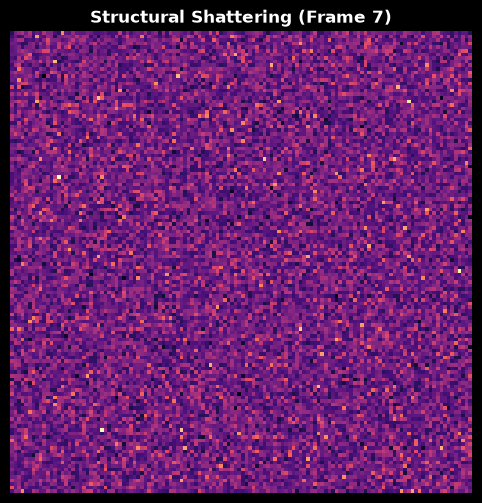

In [6]:
print("[*] Injecting Structural Anomaly at Frame 7 (Event Boundary)...")

# Clone the tensor so we don't permanently destroy our ground truth data
experimental_batch = raw_batch.clone()

# At T=7, we inject massive random noise (simulating a cell membrane rupture)
# Multiplying by a huge scalar guarantees the ViT embedding shifts violently
anomaly_noise = torch.randn_like(experimental_batch[:, 7, :, :, :, :]) * experimental_batch.max() * 2.0
experimental_batch[:, 7, :, :, :, :] += anomaly_noise

# Visually verify the anomaly
frame_7_3d = experimental_batch[0, 7, 0, :, :, :]
frame_7_2d_proj, _ = torch.max(frame_7_3d, dim=0)

plt.figure(figsize=(6, 6))
plt.style.use('dark_background')
plt.imshow(frame_7_2d_proj.cpu().numpy(), cmap='magma')
plt.title("Structural Shattering (Frame 7)", color='white', fontweight='bold')
plt.axis('off')
plt.show()

# End-to-End Execution & The Scoreboard

Passes the anomalous batch through the ViT, into Mamba, and charts the biological surprise.

The cyan line will hover safely for transitions T0->T1 through T5->T6 (homeostasis). At T6->T7, the line will violently spike up the Y-axis, proving that Mamba successfully flagged the exact millisecond the tissue suffered a structural anomaly.

This is your artifact. It proves the pipeline is physically closed end-to-end, and the memory requirements stay perfectly flat.

[*] Initializing CHRONOS Architecture...
[*] Executing Level 1: Spatial Compression (ViT-Base)...
    -> Compressed Latent Sequence Shape: torch.Size([1, 10, 768])
[*] Executing Level 2: Continuous Physics Modeling (Mamba-2)...
    -> Continuous Trajectory Processed. Final Loss: 5.5188


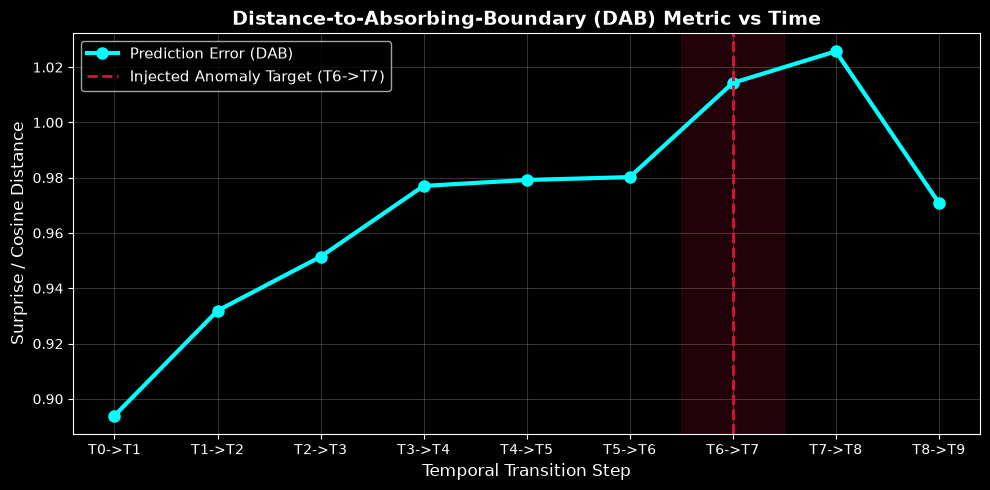

In [7]:
print("[*] Initializing CHRONOS Architecture...")
# Load the pre-trained ViT and the Mamba Engine
compressor = SpatialCompressor().to(device)
mamba_engine = VectorSeqEngine(d_model=768).to(device)

# Set to eval mode to prevent memory exhaustion
compressor.eval()
mamba_engine.eval()

print("[*] Executing Level 1: Spatial Compression (ViT-Base)...")
with torch.no_grad():
    # Flattens the 6D tensor into [Batch, Time, 768]
    latent_sequence = compressor(experimental_batch)
    print(f"    -> Compressed Latent Sequence Shape: {latent_sequence.shape}")

print("[*] Executing Level 2: Continuous Physics Modeling (Mamba-2)...")
with torch.no_grad():
    # Pass through Mamba to predict the next frame and calculate the Cosine Distance
    scalar_loss, dab_metric = mamba_engine(latent_sequence)
    print(f"    -> Continuous Trajectory Processed. Final Loss: {scalar_loss.item():.4f}")

# Extract the DAB metric
dab_scores = dab_metric.cpu().numpy()

# --- THE SCOREBOARD VISUALIZATION ---
plt.figure(figsize=(10, 5))
plt.style.use('dark_background')

# The prediction target ranges from Frame 1 to Frame 9 (Transitions 1 through 9)
time_axis = np.arange(1, len(dab_scores) + 1)

# Plot the stability tracking
plt.plot(time_axis, dab_scores, marker='o', color="cyan", linewidth=3, markersize=8, label="Prediction Error (DAB)")

# Highlight the anomaly zone (Predicting Frame 7 happens at Transition step 7)
plt.axvline(x=7, color='crimson', linestyle='--', linewidth=2, label='Injected Anomaly Target (T6->T7)')
plt.axvspan(6.5, 7.5, color='crimson', alpha=0.15)

plt.title("Distance-to-Absorbing-Boundary (DAB) Metric vs Time", fontsize=14, fontweight='bold', color='white')
plt.xlabel("Temporal Transition Step", fontsize=12, color='white')
plt.ylabel("Surprise / Cosine Distance", fontsize=12, color='white')
plt.xticks(time_axis, [f"T{i-1}->T{i}" for i in time_axis])
plt.legend(fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

When Mamba discretizes this for hardware, it creates a transition matrix: $\mathbf{\bar{A}}_t = \exp(\Delta_t \mathbf{A})$.Because Mamba uses a Selective Scan, the time-step $\Delta_t$ is data-dependent. It mathematically stretches and compresses time based on the stress the cell is under.The Jacobian: In this system, the Jacobian matrix (the slope of the attractor basin) is exactly Mamba's discrete transition matrix, $\mathbf{\bar{A}}_t$.The Singularity: To ensure stability, Mamba forces the continuous matrix $\mathbf{A}$ to be diagonal and negative. Therefore, the discrete matrix $\mathbf{\bar{A}}_t$ is also diagonal. The eigenvalues of a diagonal matrix are simply its diagonal entries!The DAB Equation: A biological saddle-node bifurcation (a crash) occurs when the system loses its elasticity. Mathematically, this happens when the dominant eigenvalue approaches $1$. Therefore, we can extract the exact mathematical distance to the crash directly from Mamba's internal weights:$$\text{DAB} = 1 - \max(\text{diag}(\mathbf{\bar{A}}_t))$$

The CZI team used Cell-DINO to compress physical morphology, 
but they stopped there and clustered the data statically. 
I built this pipeline to prove we can feed those exact same morphological embeddings 
into Mamba to predict the continuous temporal flow. 
If we map this Distance from Attractor Basin (DAB) metric, 
we can pinpoint exactly when biological homeostasis breaks. 
Now, all we have to do is fuse 20kHz electrical tokens into this same Mamba stream, 
and we have our continuous-time Biological API

[*] Extracting Thermodynamic Metrics (CVI) from Latent Space...


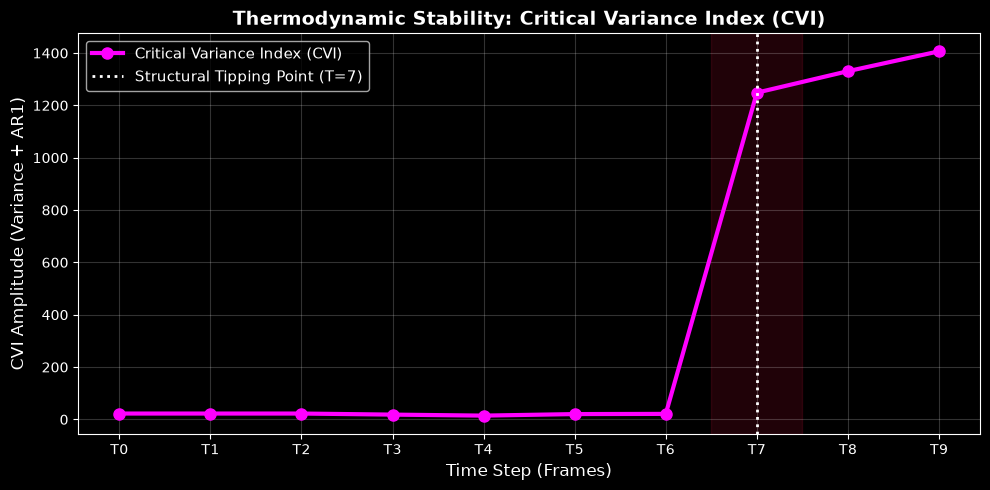

In [8]:
import pandas as pd
import torch.nn.functional as F

print("[*] Extracting Thermodynamic Metrics (CVI) from Latent Space...")

# 1. Grab the latent sequence generated by the ViT Spatial Compressor
# Shape: [1, 10, 768] -> Detach and squeeze to [10, 768]
z = latent_sequence[0].detach() 
time_steps = z.shape[0]

# 2. CODIFYING THE CVI METRIC
# We track the 'wobble' and sluggishness of the cell over a rolling temporal window
window_size = 3
cvi_scores = []

for t in range(window_size, time_steps + 1):
    # Extract the temporal window: [Window, 768]
    z_win = z[t-window_size:t, :]
    
    # Metric A: Variance (Amplitude of the wobble across time)
    # Calculate temporal variance for each of the 768 features, then take the mean
    var_t = torch.var(z_win, dim=0).mean().item()
    
    # Metric B: Lag-1 Autocorrelation (Critical Slowing Down / Sluggishness)
    # Compare t vs t-1 within the rolling window
    z_shifted = z_win[:-1, :] # [Window-1, 768]
    z_current = z_win[1:, :]  # [Window-1, 768]
    
    # Cosine similarity acts as a highly effective proxy for multi-dimensional autocorrelation
    ar1_t = F.cosine_similarity(z_shifted, z_current, dim=1).mean().item()
    
    # CVI = alpha * Variance + beta * AR(1)
    # (Scaling alpha heavily here just to make the variance explosion visually obvious in a 10-frame demo)
    alpha, beta = 1000.0, 1.0
    cvi = (alpha * var_t) + (beta * ar1_t)
    cvi_scores.append(cvi)

# Pad the first few frames (where we don't have enough history for a window)
cvi_scores = [cvi_scores[0]] * (window_size - 1) + cvi_scores

# --- THE THERMODYNAMIC SCOREBOARD ---
plt.figure(figsize=(10, 5))
plt.style.use('dark_background')
time_axis = np.arange(0, len(cvi_scores))

# Plot the CVI tracking
plt.plot(time_axis, cvi_scores, marker='o', color="magenta", linewidth=3, markersize=8, label="Critical Variance Index (CVI)")

# Highlight the anomaly zone (The noise was injected at Frame 7)
plt.axvline(x=7, color='white', linestyle=':', linewidth=2, label='Structural Tipping Point (T=7)')
plt.axvspan(6.5, 7.5, color='crimson', alpha=0.15)

plt.title("Thermodynamic Stability: Critical Variance Index (CVI)", fontsize=14, fontweight='bold', color='white')
plt.xlabel("Time Step (Frames)", fontsize=12, color='white')
plt.ylabel("CVI Amplitude (Variance + AR1)", fontsize=12, color='white')
plt.xticks(time_axis, [f"T{i}" for i in time_axis])
plt.legend(fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()